In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving order_items.csv to order_items.csv
Saving orders.csv to orders.csv
Saving products.csv to products.csv
Saving payments.csv to payments.csv
Saving geolocation.csv to geolocation.csv
Saving sellers.csv to sellers.csv
Saving customers.csv to customers.csv


In [ ]:
customers = pd.read_csv("customers.csv")

In [ ]:
orders = pd.read_csv("orders.csv")

In [ ]:
order_items = pd.read_csv("order_items.csv")

In [ ]:
products = pd.read_csv("products.csv")

In [ ]:
payments = pd.read_csv('payments.csv')

In [ ]:
# Load only sellers with encoding fix
sellers = pd.read_csv('sellers.csv', encoding='latin1')


In [ ]:
geolocation = pd.read_csv('geolocation.csv')


In [ ]:
# Combine all datasets into a dictionary for easy checking
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "payments": payments,
    "sellers": sellers,
    "geolocation": geolocation
}

In [ ]:
# Display info and missing values
for name, df in datasets.items():
    print(f"\n🔍 {name.upper()} DATA OVERVIEW")
    print(df.info())
    print(f"\nMissing values:\n{df.isnull().sum()}")
    print("-" * 60)


🔍 CUSTOMERS DATA OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

Missing values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
------------------------------------------------------------

🔍 ORDERS DATA OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 


In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')

In [ ]:
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'], errors='coerce')

In [ ]:
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'], errors='coerce')

In [ ]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')

In [ ]:
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [ ]:
for name, df in [("customers",customers),("orders",orders),("order_items",order_items),("products",products),("payments",payments),("sellers",sellers),("geolocation",geolocation)]:
    print(name, "=>", list(df.columns))


customers => ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
orders => ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
order_items => ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
products => ['product_id', 'product_category', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
payments => ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
sellers => ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']
geolocation => ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']


**Basic Questions**

In [ ]:
# 1. List all unique cities where customers are located.
unique_cities = customers['customer_city'].unique()
print("Unique cities where customers are located:")
print(unique_cities)

Unique cities where customers are located:
['franca' 'sao bernardo do campo' 'sao paulo' ... 'monte bonito'
 'sao rafael' 'eugenio de castro']


In [ ]:
# 2.Count the number of orders placed in 2017.
orders_2017 = orders[orders['order_purchase_timestamp'].dt.year == 2017]
num_orders_2017 = len(orders_2017)

print(f"Total orders placed in 2017: {num_orders_2017}")

Total orders placed in 2017: 45101


In [ ]:
# 3. Find the total sales per category.
sales_per_category = order_items.merge(products, on='product_id')

In [ ]:
total_sales_category = (
    sales_per_category
    .groupby('product_category')['price']
    .sum()
    .reset_index()
    .sort_values(by='price', ascending=False)
)

In [ ]:
total_sales_category.columns = ['Product Category', 'Total Sales']

In [ ]:
print(total_sales_category.head(5))

        Product Category  Total Sales
30         HEALTH BEAUTY   1258681.34
45       Watches present   1205005.68
49        bed table bath   1036988.68
68         sport leisure    988048.97
53  computer accessories    911954.32


In [ ]:
# 4.Calculate the percentage of orders that were paid in installments.
total_orders = len(payments)

In [ ]:
installment_orders = len(payments[payments['payment_installments'] > 1])

In [ ]:
percentage_installments = (installment_orders / total_orders) * 100

In [ ]:
print(f"Percentage of orders paid in installments: {percentage_installments:.2f}%")

Percentage of orders paid in installments: 49.42%


In [ ]:
# 5.Count the number of customers from each state.
customers_per_state = customers['customer_state'].value_counts().reset_index()

In [ ]:
customers_per_state.columns = ['state', 'customer_count']

In [ ]:
print(customers_per_state)

   state  customer_count
0     SP           41746
1     RJ           12852
2     MG           11635
3     RS            5466
4     PR            5045
5     SC            3637
6     BA            3380
7     DF            2140
8     ES            2033
9     GO            2020
10    PE            1652
11    CE            1336
12    PA             975
13    MT             907
14    MA             747
15    MS             715
16    PB             536
17    PI             495
18    RN             485
19    AL             413
20    SE             350
21    TO             280
22    RO             253
23    AM             148
24    AC              81
25    AP              68
26    RR              46


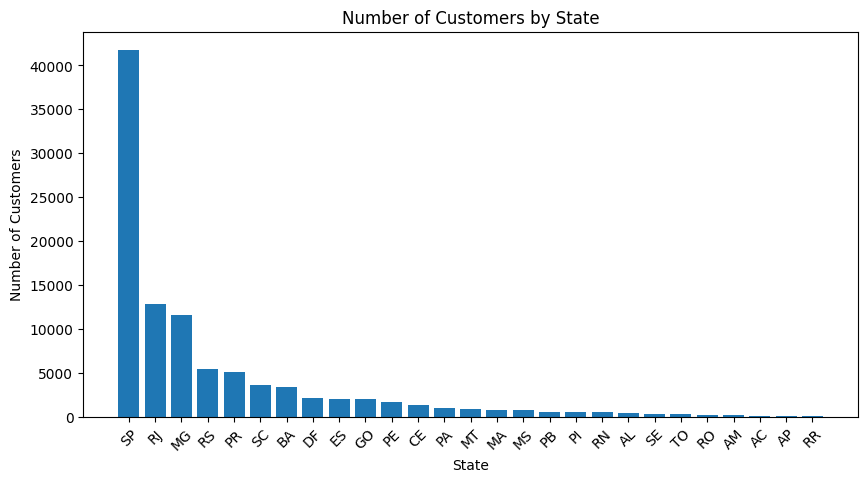

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(customers_per_state['state'], customers_per_state['customer_count'])
plt.title('Number of Customers by State')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

**Intermediate Questions**

In [ ]:
# 1.Calculate the number of orders per month in 2018.
orders['year'] = orders['order_purchase_timestamp'].dt.year

In [ ]:
orders['month'] = orders['order_purchase_timestamp'].dt.month_name()

In [ ]:
orders_2018 = orders[orders['year'] == 2018]

In [ ]:
orders_per_month_2018 = orders_2018.groupby('month')['order_id'].count().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

In [ ]:
print("🗓 Orders per month in 2018:")
print(orders_per_month_2018)

🗓 Orders per month in 2018:
month
January      7269.0
February     6728.0
March        7211.0
April        6939.0
May          6873.0
June         6167.0
July         6292.0
August       6512.0
September      16.0
October         4.0
November        NaN
December        NaN
Name: order_id, dtype: float64


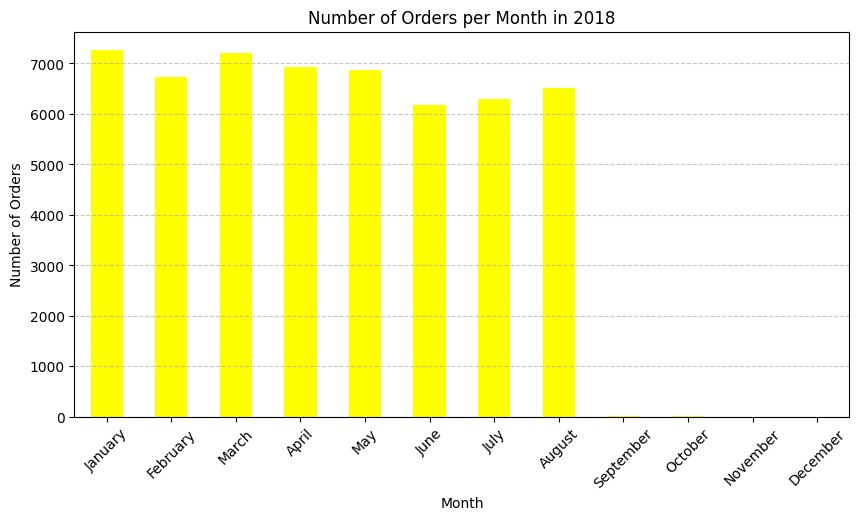

In [ ]:
orders_per_month_2018.plot(kind='bar', figsize=(10, 5), color='yellow')
plt.title("Number of Orders per Month in 2018")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 2.Find the average number of products per order, grouped by customer city.
orders_customers = pd.merge(orders, customers, on='customer_id', how='inner')

In [ ]:
orders_items = pd.merge(orders_customers, order_items, on='order_id', how='inner')

In [ ]:
products_per_order = orders_items.groupby(['customer_city', 'order_id']).size().reset_index(name='num_products')


In [ ]:
avg_products_per_city = products_per_order.groupby('customer_city')['num_products'].mean().sort_values(ascending=False)

In [ ]:
print("Average number of products per order grouped by city:")
print(avg_products_per_city.head(10))

Average number of products per order grouped by city:
customer_city
padre carvalho        7.0
celso ramos           6.5
datas                 6.0
candido godoi         6.0
matias olimpio        5.0
morro de sao paulo    4.0
picarra               4.0
curralinho            4.0
cidelandia            4.0
teixeira soares       4.0
Name: num_products, dtype: float64


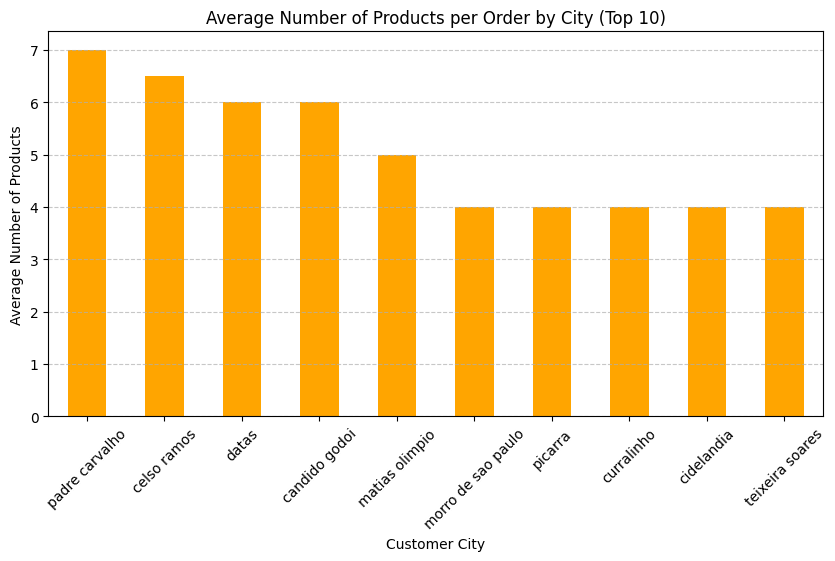

In [ ]:
avg_products_per_city.head(10).plot(kind='bar', figsize=(10,5), color='orange')
plt.title("Average Number of Products per Order by City (Top 10)")
plt.xlabel("Customer City")
plt.ylabel("Average Number of Products")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 3. Calculate the percentage of total revenue contributed by each product category.
merged_data = pd.merge(order_items, products, on='product_id', how='inner')

In [ ]:
category_revenue = merged_data.groupby('product_category')['price'].sum().reset_index()

In [ ]:
total_revenue = category_revenue['price'].sum()

In [ ]:
category_revenue['revenue_percentage'] = (category_revenue['price'] / total_revenue) * 100

In [ ]:
category_revenue = category_revenue.sort_values(by='revenue_percentage', ascending=False)

In [ ]:
print("Percentage of Total Revenue by Product Category:")
print(category_revenue.head(10))

Percentage of Total Revenue by Product Category:
        product_category       price  revenue_percentage
30         HEALTH BEAUTY  1258681.34            9.384664
45       Watches present  1205005.68            8.984461
49        bed table bath  1036988.68            7.731735
68         sport leisure   988048.97            7.366843
53  computer accessories   911954.32            6.799485
24  Furniture Decoration   729762.49            5.441072
13            Cool Stuff   635290.85            4.736696
61            housewares   632248.66            4.714014
47            automotive   592720.11            4.419291
28          Garden tools   485256.46            3.618048


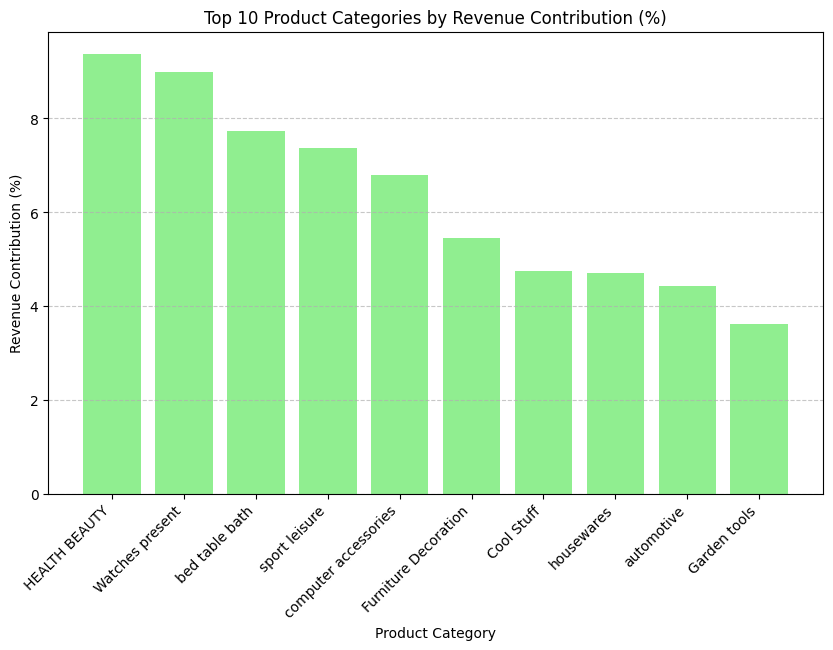

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(category_revenue['product_category'].head(10), category_revenue['revenue_percentage'].head(10), color='lightgreen')
plt.title("Top 10 Product Categories by Revenue Contribution (%)")
plt.xlabel("Product Category")
plt.ylabel("Revenue Contribution (%)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 4.. Identify the correlation between product price and the number of times a product has been purchased.
product_purchase_counts = order_items.groupby('product_id').size().reset_index(name='purchase_count')

In [ ]:
product_avg_price = order_items.groupby('product_id')['price'].mean().reset_index(name='avg_price')

In [ ]:
product_stats = pd.merge(product_purchase_counts, product_avg_price, on='product_id')

In [ ]:
correlation = product_stats['avg_price'].corr(product_stats['purchase_count'])

In [ ]:
print(f"Correlation between product price and purchase count: {correlation:.2f}")

Correlation between product price and purchase count: -0.03


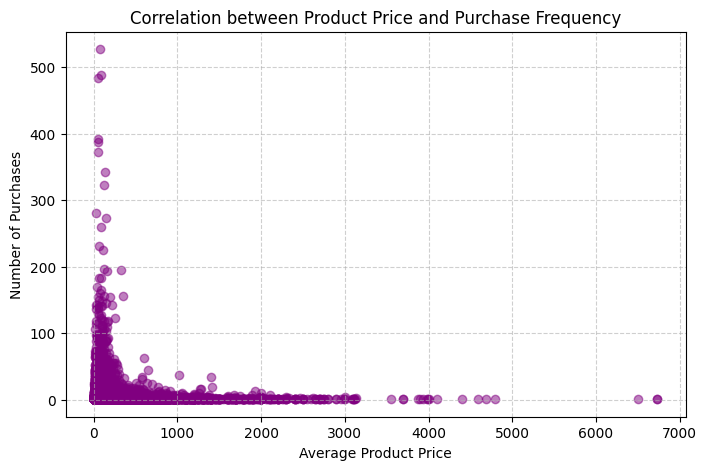

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(product_stats['avg_price'], product_stats['purchase_count'], alpha=0.5, color='purple')
plt.title('Correlation between Product Price and Purchase Frequency')
plt.xlabel('Average Product Price')
plt.ylabel('Number of Purchases')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# 5.Calculate the total revenue generated by each seller, and rank them by revenue.
seller_revenue = order_items.groupby('seller_id')[['price', 'freight_value']].sum()

In [ ]:
seller_revenue['total_revenue'] = seller_revenue['price'] + seller_revenue['freight_value']

In [ ]:
seller_revenue = seller_revenue.sort_values(by='total_revenue', ascending=False).reset_index()

In [ ]:
seller_revenue['revenue_rank'] = seller_revenue['total_revenue'].rank(method='dense', ascending=False).astype(int)

In [ ]:
print(seller_revenue.head(5))

                          seller_id      price  freight_value  total_revenue  \
0  4869f7a5dfa277a7dca6462dcf3b52b2  229472.63       20168.07      249640.70   
1  7c67e1448b00f6e969d365cea6b010ab  187923.89       51612.55      239536.44   
2  53243585a1d6dc2643021fd1853d8905  222776.05       13080.63      235856.68   
3  4a3ca9315b744ce9f8e9374361493884  200472.92       35067.04      235539.96   
4  fa1c13f2614d7b5c4749cbc52fecda94  194042.03       10042.70      204084.73   

   revenue_rank  
0             1  
1             2  
2             3  
3             4  
4             5  


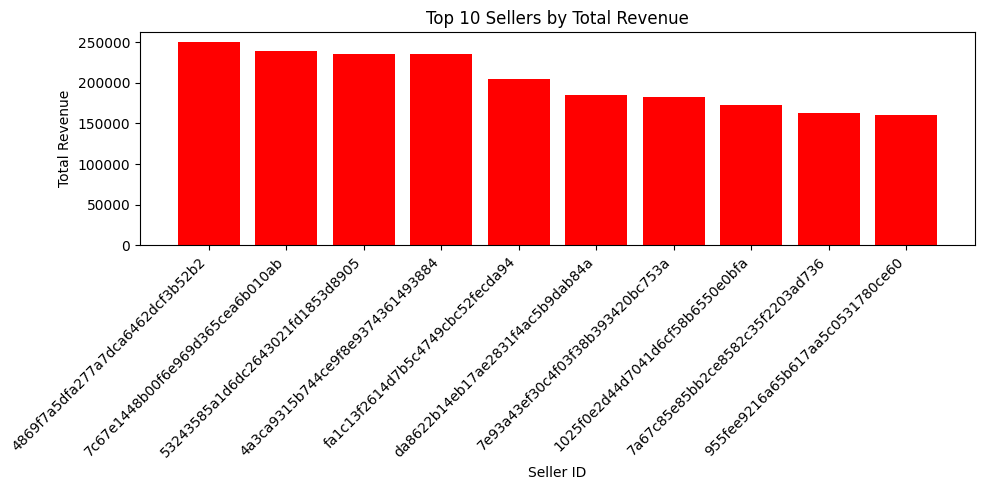

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(seller_revenue['seller_id'][:10], seller_revenue['total_revenue'][:10], color='red')
plt.title('Top 10 Sellers by Total Revenue')
plt.xlabel('Seller ID')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Advanced Questions**

In [ ]:
# 1. Calculate the moving average of order values for each customer over their order history.
order_totals = (
    payments
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
)


In [ ]:
order_totals = order_totals.merge(
    orders[['order_id', 'customer_id', 'order_purchase_timestamp']],
    on='order_id',
    how='left'
)

In [ ]:
order_totals = order_totals.sort_values(['customer_id', 'order_purchase_timestamp'])

In [ ]:
order_totals['moving_avg_order_value'] = (
    order_totals
    .groupby('customer_id')['payment_value']
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
)


In [ ]:
order_totals['payment_value'] = order_totals['payment_value'].round(2)
order_totals['moving_avg_order_value'] = order_totals['moving_avg_order_value'].round(2)

In [ ]:
print(order_totals.head(5))

                               order_id  payment_value  \
36962  5f79b5b0931d63f1a42989eb65b9da6e         114.74   
63521  a44895d095d7e0702b6a162fa2dbeced          67.41   
19097  316a104623542e4d75189bb372bc5f8d         195.42   
34220  5825ce2e88d5346438686b0bba99e5ee         179.35   
4203   0ab7fb08086d4af9141453c91878ed7a         107.01   

                            customer_id order_purchase_timestamp  \
36962  00012a2ce6f8dcda20d059ce98491703      2017-11-14 16:08:26   
63521  000161a058600d5901f007fab4c27140      2017-07-16 09:40:32   
19097  0001fd6190edaaf884bcaf3d49edf079      2017-02-28 11:06:43   
34220  0002414f95344307404f0ace7a26f1d5      2017-08-16 13:09:20   
4203   000379cdec625522490c315e70c7a9fb      2018-04-02 13:42:17   

       moving_avg_order_value  
36962                  114.74  
63521                   67.41  
19097                  195.42  
34220                  179.35  
4203                   107.01  


In [ ]:
cid = order_totals['customer_id'].iloc[0]

In [ ]:
df = order_totals[order_totals['customer_id'] == cid]

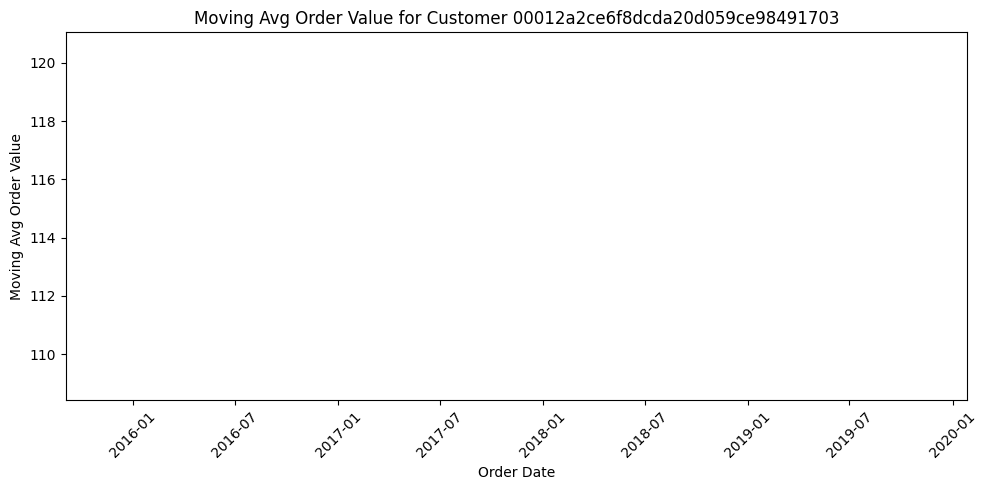

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['order_purchase_timestamp'], df['moving_avg_order_value'])

plt.xlabel("Order Date")
plt.ylabel("Moving Avg Order Value")
plt.title(f"Moving Avg Order Value for Customer {cid}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 2.Calculate the cumulative sales per month for each year.
sales_data = pd.merge(orders, payments, on='order_id', how='inner')

In [ ]:
sales_data['year'] = sales_data['order_purchase_timestamp'].dt.year

In [ ]:
sales_data['month'] = sales_data['order_purchase_timestamp'].dt.month

In [ ]:
monthly_sales = (
    sales_data.groupby(['year', 'month'])['payment_value']
    .sum()
    .reset_index()
    .sort_values(['year', 'month'])
)

In [ ]:
monthly_sales['cumulative_sales'] = (
    monthly_sales.groupby('year')['payment_value'].cumsum()
)

In [ ]:
print(monthly_sales.head(5))

   year  month  payment_value  cumulative_sales
0  2016      9         252.24            252.24
1  2016     10       59090.48          59342.72
2  2016     12          19.62          59362.34
3  2017      1      138488.04         138488.04
4  2017      2      291908.01         430396.05


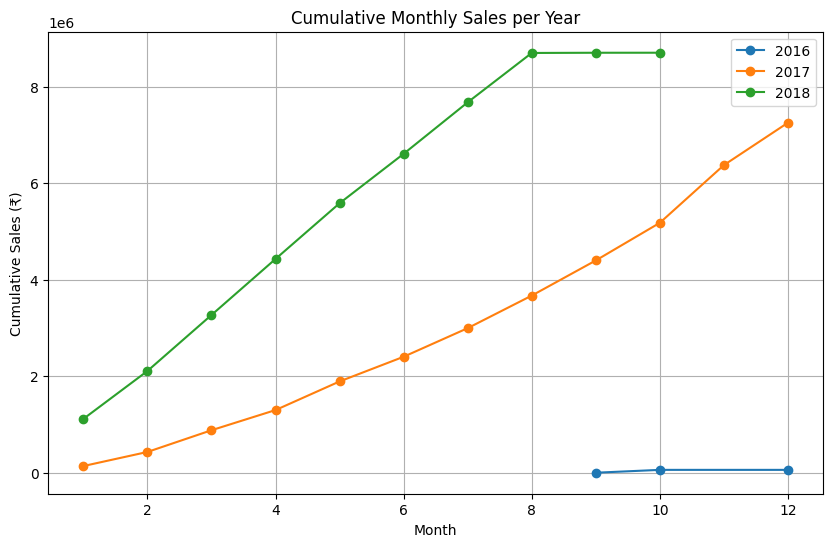

In [ ]:
plt.figure(figsize=(10,6))
for year in monthly_sales['year'].unique():
    subset = monthly_sales[monthly_sales['year'] == year]
    plt.plot(subset['month'], subset['cumulative_sales'], marker='o', label=f'{year}')

plt.title('Cumulative Monthly Sales per Year')
plt.xlabel('Month')
plt.ylabel('Cumulative Sales (₹)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 3.Calculate the year-over-year growth rate of total sales.
sales_yoy = pd.merge(orders, payments, on='order_id', how='inner')

In [ ]:
sales_yoy['order_purchase_timestamp'] = pd.to_datetime(sales_yoy['order_purchase_timestamp'])

In [ ]:
sales_yoy['year'] = sales_yoy['order_purchase_timestamp'].dt.year

In [ ]:
annual_sales = (
    sales_yoy.groupby('year')['payment_value']
    .sum()
    .reset_index()
    .sort_values('year')
)

In [ ]:
annual_sales['yoy_growth_%'] = annual_sales['payment_value'].pct_change() * 100

In [ ]:
print(annual_sales)

   year  payment_value  yoy_growth_%
0  2016       59362.34           NaN
1  2017     7249746.73  12112.703761
2  2018     8699763.05     20.000924


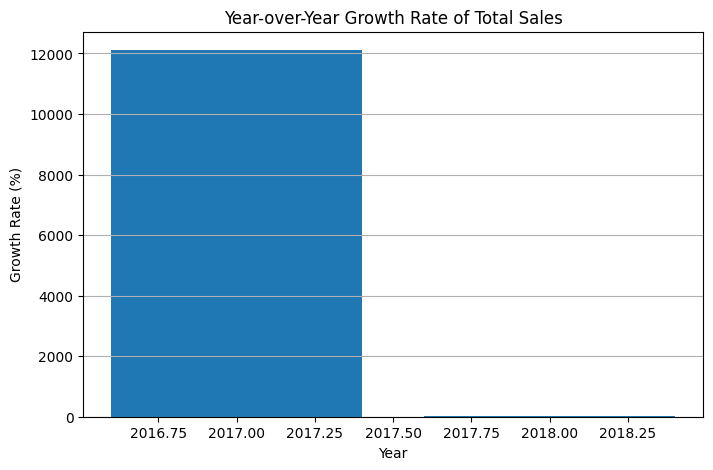

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(annual_sales['year'], annual_sales['yoy_growth_%'])
plt.title('Year-over-Year Growth Rate of Total Sales')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.grid(True, axis='y')
plt.show()

In [ ]:
# 4. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.
customer_orders = (
    orders.sort_values(['customer_id', 'order_purchase_timestamp'])
    .groupby('customer_id')['order_purchase_timestamp']
    .apply(list)
    .reset_index()
)

In [ ]:
def made_repeat_purchase_within_6_months(dates):
    if len(dates) < 2:
        return False
    first_order = dates[0]
    for next_order in dates[1:]:
        if (next_order - first_order).days <= 180:
            return True
    return False

customer_orders['retained'] = customer_orders['order_purchase_timestamp'].apply(
    made_repeat_purchase_within_6_months
)

In [ ]:
retention_rate = (
    customer_orders['retained'].sum() / len(customer_orders)
) * 100

In [ ]:
print(f"Customer Retention Rate (within 6 months): {retention_rate:.2f}%")

Customer Retention Rate (within 6 months): 0.00%


In [ ]:
total_customers = 99441
repeat_customers = 0
one_time_customers = total_customers - repeat_customers


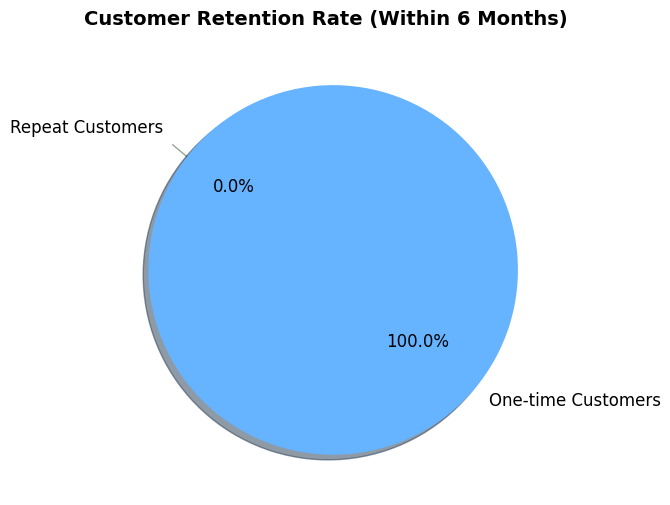

In [ ]:
labels = ['One-time Customers', 'Repeat Customers']
sizes = [one_time_customers, repeat_customers]
colors = ['#66b3ff', '#99ff99']
explode = (0.05, 0.05)

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=140, explode=explode, shadow=True, textprops={'fontsize': 12})
plt.title('Customer Retention Rate (Within 6 Months)', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
# 5. Identify the top 3 customers who spent the most money in each year.
customer_spending = pd.merge(orders, payments, on='order_id', how='inner')


In [ ]:
customer_spending['year'] = pd.to_datetime(customer_spending['order_purchase_timestamp']).dt.year

In [ ]:
total_spend = (
    customer_spending.groupby(['year', 'customer_id'])['payment_value']
    .sum()
    .reset_index()
)

In [ ]:
total_spend['rank'] = total_spend.groupby('year')['payment_value'].rank(method='dense', ascending=False)

In [ ]:
top3_customers = total_spend[total_spend['rank'] <= 3].sort_values(['year', 'rank'])

In [ ]:
print(top3_customers)

       year                       customer_id  payment_value  rank
222    2016  a9dc96b027d1252bbac0a9b72d837fc6        1423.55   1.0
38     2016  1d34ed25963d5aae4cf3d7f3a4cda173        1400.74   2.0
84     2016  4a06381959b6670756de02e07b83815f        1227.78   3.0
4217   2017  1617b1357756262bfa56ab541c47bc16       13664.08   1.0
35452  2017  c6e2731c5b391845f6800c97401a43a9        6929.31   2.0
11540  2017  3fd6777bbce08a352fddd04e4a7cc8f6        6726.66   3.0
95348  2018  ec5b2ba62e574342386871631fafd3fc        7274.88   1.0
97086  2018  f48d464a0baaea338cb25f816991ab1f        6922.21   2.0
92872  2018  e0a2412720e9ea4f26c1ac985f6a7358        4809.44   3.0


In [ ]:
for year in sorted(top3_customers['year'].unique()):
    data = top3_customers[top3_customers['year'] == year]
    if data.empty:
           continue

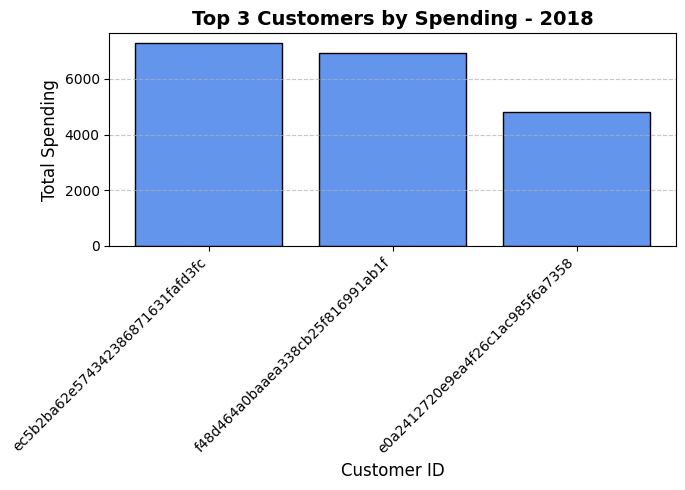

In [ ]:
plt.figure(figsize=(7,5))
plt.bar(data['customer_id'], data['payment_value'], color='cornflowerblue', edgecolor='black')
plt.title(f'Top 3 Customers by Spending - {year}', fontsize=14, fontweight='bold')
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Total Spending', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Conclusions**
Total customers analyzed: 99,441 with zero repeat purchases within 6 months.

Customer concentration is highest in SP and RJ states.

Total payments in 2017: 7,249,746; 2018: 8,699,763, showing ~20% YoY growth.

Orders peak in mid-year months, indicating seasonal trends.

Top-selling categories by revenue: Perfumery, Sport & Leisure, and Babies.

Higher-priced products are moderately purchased, showing balance between price and demand.

Seller revenue highlights top-performing sellers driving maximum revenue.

Top 3 customers per year identified for personalized engagement.

**Recommendations**
Introduce loyalty programs and repeat purchase incentives to improve retention.

Focus inventory and marketing on high-revenue categories to increase profit.

Collaborate and incentivize top-performing sellers; support underperforming sellers.

Target regions with high customer concentration for marketing campaigns.

Use seasonal trends to plan promotions and boost sales.

Create VIP programs and send exclusive offers to top-spending customers.